In [2]:
import pandas as pd

In [3]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [8]:
target = "SalePrice"

print("Target exists:", target in train.columns)
print("Target data type:", train[target].dtype)
print("Example target values:")
print(train[target].head())

Target exists: True
Target data type: int64
Example target values:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [10]:
print('target column:', target)
print("Problem type Regression")

target column: SalePrice
Problem type Regression


In [11]:
print(train.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [12]:
numerical_cols = train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = train.select_dtypes(include=["object"]).columns

print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Number of numerical columns: 38
Number of categorical columns: 43

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',

C:\Users\User\AppData\Local\Temp\ipykernel_16024\1737509073.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=["object"]).columns


In [13]:
numerical_features = numerical_cols.drop("SalePrice")

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_cols))

Number of numerical features: 37
Number of categorical features: 43


In [14]:
missing_count = train.isnull().sum()
missing_percent = (train.isnull().sum() / len(train)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table = missing_table.sort_values(by="Missing Count", ascending=False)

missing_table.head(10)

,Missing Count,Missing Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [15]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [17]:
print("Mean SalePrice:", train["SalePrice"].mean())
print("Median SalePrice:", train["SalePrice"].median())
print("Skewness:", train["SalePrice"].skew())

Mean SalePrice: 180921.19589041095
Median SalePrice: 163000.0
Skewness: 1.8828757597682129


<Axes: >

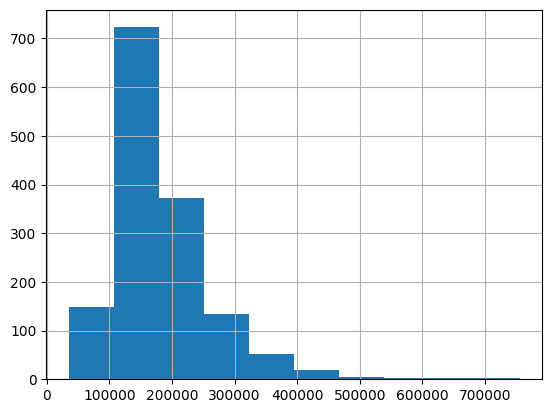

In [18]:
train["SalePrice"].hist()

<Axes: >

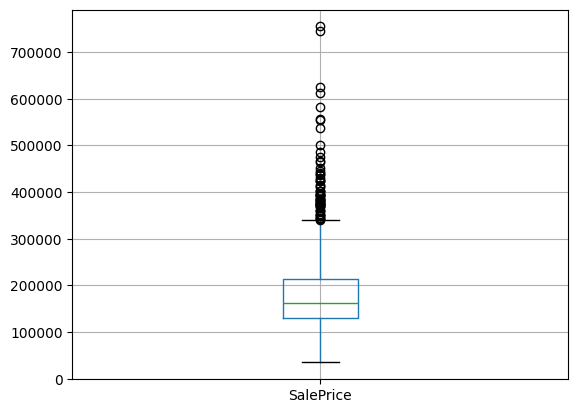

In [19]:
train.boxplot(column="SalePrice")

In [20]:
print("Train columns:", train.shape[1])
print("Test columns:", test.shape[1])
train_only_columns = set(train.columns) - set(test.columns)

print("Columns in train but not in test:")
print(train_only_columns)

Train columns: 81
Test columns: 80
Columns in train but not in test:
{'SalePrice'}
